In [2]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost plotly -q

In [3]:
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [4]:
# Generate realistic supply chain sales data
np.random.seed(42)

# Create date range
dates = pd.date_range(start='2022-01-01', end='2024-12-31', freq='D')

# Products and categories
products = ['Product_A', 'Product_B', 'Product_C', 'Product_D', 'Product_E']
categories = ['Electronics', 'Clothing', 'Food', 'Sports', 'Home']

data = []
for product, category in zip(products, categories):
    for date in dates:
        # Simulate demand with seasonality and trend
        base_demand = np.random.randint(50, 200)
        seasonality = 20 * np.sin(2 * np.pi * date.dayofyear / 365)
        trend = 0.05 * (date.year - 2022) * 365 + date.dayofyear
        noise = np.random.normal(0, 10)
        demand = max(0, base_demand + seasonality + trend * 0.1 + noise)

        data.append({
            'date': date,
            'product': product,
            'category': category,
            'demand': round(demand, 2),
            'price': round(np.random.uniform(10, 500), 2),
            'promotion': np.random.choice([0, 1], p=[0.8, 0.2]),
            'holiday': 1 if date.month in [11, 12] else 0,
            'stock_level': np.random.randint(100, 1000)
        })

df = pd.DataFrame(data)
print("✅ Dataset created successfully!")
print(f"Shape: {df.shape}")
print(df.head())

✅ Dataset created successfully!
Shape: (5480, 8)
        date    product     category  demand   price  promotion  holiday  \
0 2022-01-01  Product_A  Electronics  146.94  392.05          0        0   
1 2022-01-02  Product_A  Electronics  130.04  235.03          0        0   
2 2022-01-03  Product_A  Electronics  176.64   99.09          0        0   
3 2022-01-04  Product_A  Electronics  114.20  267.13          0        0   
4 2022-01-05  Product_A  Electronics  104.90  487.14          0        0   

   stock_level  
0          221  
1          971  
2          559  
3          660  
4          786  


In [5]:
# Feature Engineering
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek
df['quarter'] = df['date'].dt.quarter
df['dayofyear'] = df['date'].dt.dayofyear
df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)

# Lag features
df = df.sort_values(['product', 'date'])
df['lag_1'] = df.groupby('product')['demand'].shift(1)
df['lag_7'] = df.groupby('product')['demand'].shift(7)
df['lag_30'] = df.groupby('product')['demand'].shift(30)

# Rolling mean features
df['rolling_mean_7'] = df.groupby('product')['demand'].transform(lambda x: x.rolling(7).mean())
df['rolling_mean_30'] = df.groupby('product')['demand'].transform(lambda x: x.rolling(30).mean())

# Encode categorical columns
le = LabelEncoder()
df['product_encoded'] = le.fit_transform(df['product'])
df['category_encoded'] = le.fit_transform(df['category'])

# Drop nulls
df = df.dropna()

print("✅ Feature Engineering Done!")
print(f"Shape: {df.shape}")
print(df.head())

✅ Feature Engineering Done!
Shape: (5330, 22)
         date    product     category  demand   price  promotion  holiday  \
30 2022-01-31  Product_A  Electronics  170.86  179.08          0        0   
31 2022-02-01  Product_A  Electronics  191.83  270.16          0        0   
32 2022-02-02  Product_A  Electronics  128.92  128.66          1        0   
33 2022-02-03  Product_A  Electronics  172.56  491.88          0        0   
34 2022-02-04  Product_A  Electronics  202.90  101.39          0        0   

    stock_level  year  month  ...  quarter  dayofyear  weekofyear   lag_1  \
30          737  2022      1  ...        1         31           5   93.65   
31          809  2022      2  ...        1         32           5  170.86   
32          936  2022      2  ...        1         33           5  191.83   
33          610  2022      2  ...        1         34           5  128.92   
34          759  2022      2  ...        1         35           5  172.56   

     lag_7  lag_30  rolling_

In [6]:
# Prepare data for training
features = ['year', 'month', 'day', 'dayofweek', 'quarter', 'dayofyear',
            'weekofyear', 'price', 'promotion', 'holiday', 'stock_level',
            'lag_1', 'lag_7', 'lag_30', 'rolling_mean_7', 'rolling_mean_30',
            'product_encoded', 'category_encoded']

target = 'demand'

X = df[features]
y = df[target]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost model
model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("✅ Model Trained Successfully!")
print(f"📊 MAE  : {mae:.2f}")
print(f"📊 RMSE : {rmse:.2f}")
print(f"📊 MAPE : {mape:.2f}%")

✅ Model Trained Successfully!
📊 MAE  : 34.85
📊 RMSE : 41.75
📊 MAPE : 28.06%


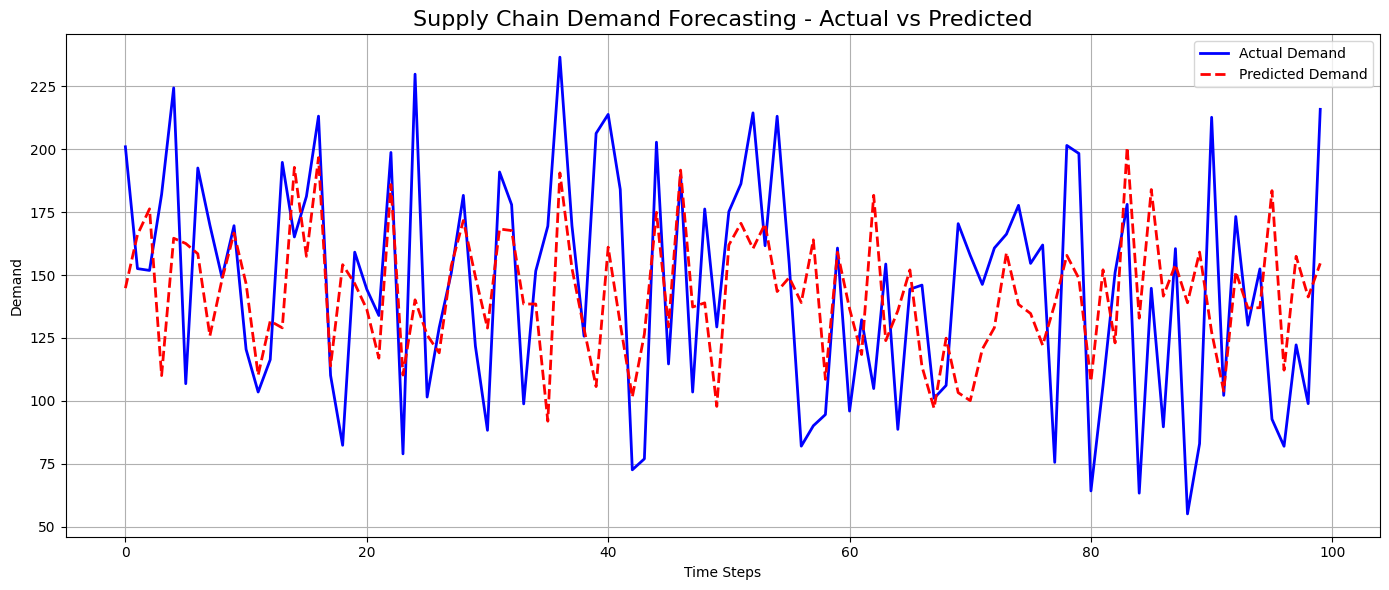

✅ Plot 1 Done!


In [7]:
# Visualization 1 - Actual vs Predicted
plt.figure(figsize=(14, 6))
plt.plot(y_test.values[:100], label='Actual Demand', color='blue', linewidth=2)
plt.plot(y_pred[:100], label='Predicted Demand', color='red', linewidth=2, linestyle='--')
plt.title('Supply Chain Demand Forecasting - Actual vs Predicted', fontsize=16)
plt.xlabel('Time Steps')
plt.ylabel('Demand')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png')
plt.show()
print("✅ Plot 1 Done!")

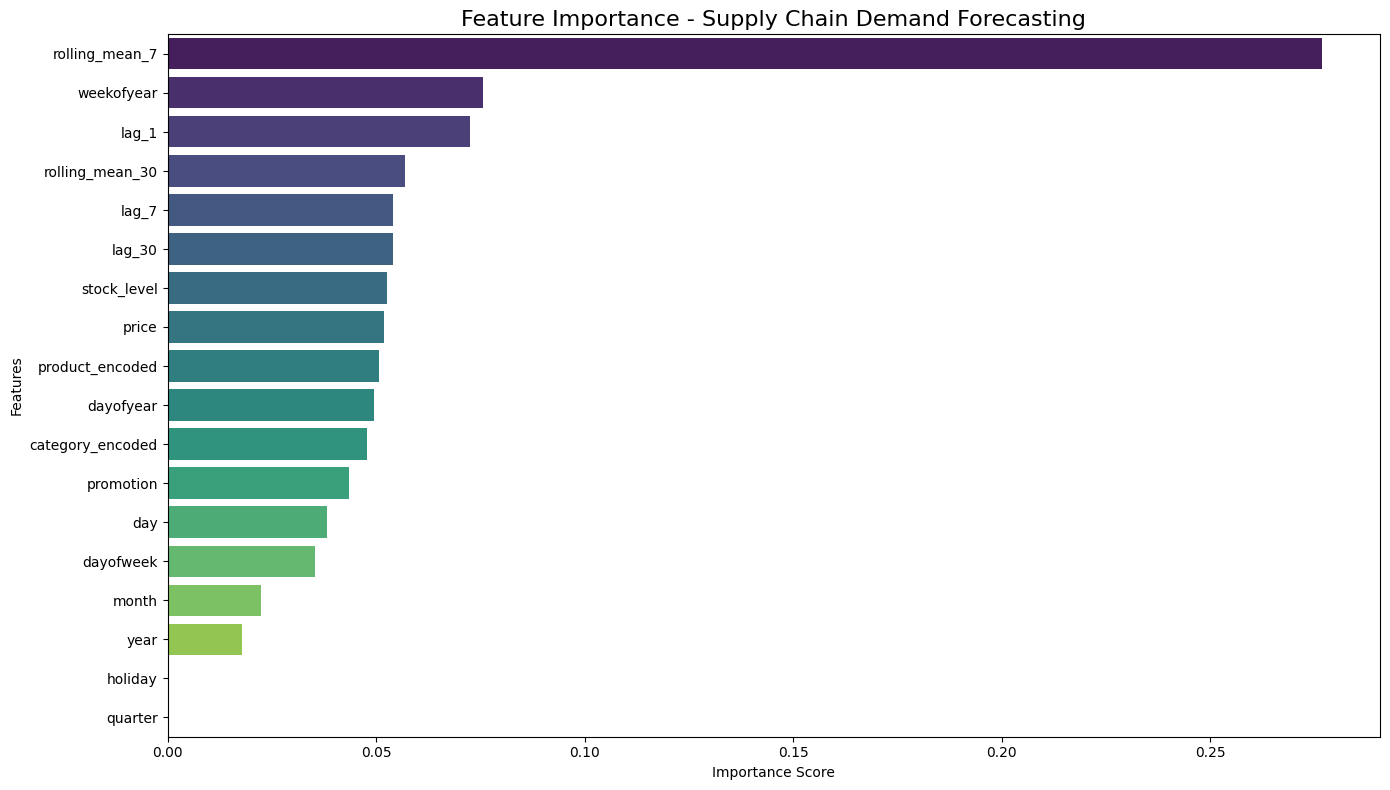

✅ Plot 2 Done!


In [8]:
# Visualization 2 - Feature Importance
plt.figure(figsize=(14, 8))
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

sns.barplot(x='importance', y='feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance - Supply Chain Demand Forecasting', fontsize=16)
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()
print("✅ Plot 2 Done!")

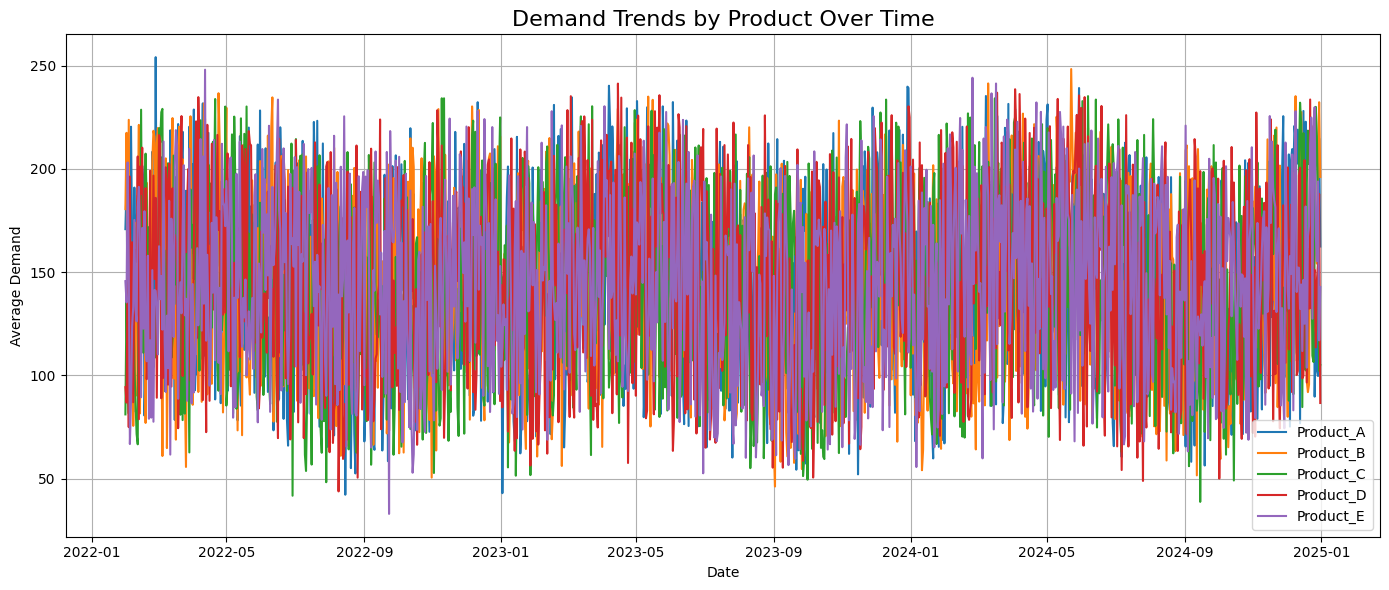

✅ Plot 3 Done!


In [9]:
# Visualization 3 - Demand Trends by Product
plt.figure(figsize=(14, 6))
for product in products:
    product_data = df[df['product'] == product].groupby('date')['demand'].mean()
    plt.plot(product_data.index, product_data.values, label=product, linewidth=1.5)

plt.title('Demand Trends by Product Over Time', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Average Demand')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('demand_trends.png')
plt.show()
print("✅ Plot 3 Done!")

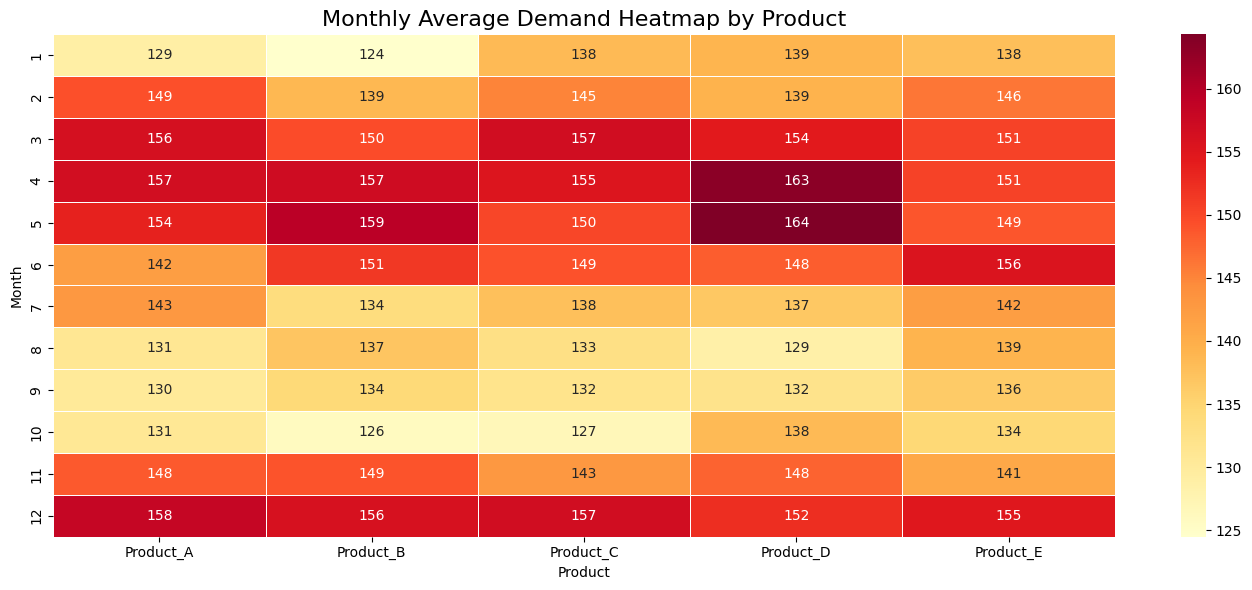

✅ Plot 4 Done!


In [10]:
# Visualization 4 - Monthly Demand Heatmap
plt.figure(figsize=(14, 6))
df_heatmap = df.groupby(['month', 'product'])['demand'].mean().unstack()
sns.heatmap(df_heatmap, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Monthly Average Demand Heatmap by Product', fontsize=16)
plt.xlabel('Product')
plt.ylabel('Month')
plt.tight_layout()
plt.savefig('demand_heatmap.png')
plt.show()
print("✅ Plot 4 Done!")

In [11]:
# Final Summary Report
print("=" * 60)
print("   SUPPLY CHAIN DEMAND FORECASTING - PROJECT SUMMARY")
print("=" * 60)
print(f"\n📦 Dataset Info:")
print(f"   Total Records     : {df.shape[0]}")
print(f"   Total Features    : {df.shape[1]}")
print(f"   Products          : {df['product'].nunique()}")
print(f"   Categories        : {df['category'].nunique()}")
print(f"   Date Range        : {df['date'].min().date()} to {df['date'].max().date()}")

print(f"\n🤖 Model Info:")
print(f"   Algorithm         : XGBoost Regressor")
print(f"   Training Samples  : {X_train.shape[0]}")
print(f"   Testing Samples   : {X_test.shape[0]}")
print(f"   Total Features    : {len(features)}")

print(f"\n📊 Model Performance:")
print(f"   MAE               : {mae:.2f}")
print(f"   RMSE              : {rmse:.2f}")
print(f"   MAPE              : {mape:.2f}%")

print(f"\n✅ Visualizations Saved:")
print(f"   - actual_vs_predicted.png")
print(f"   - feature_importance.png")
print(f"   - demand_trends.png")
print(f"   - demand_heatmap.png")
print("\n" + "=" * 60)
print("   PROJECT COMPLETED SUCCESSFULLY! 🎉")
print("=" * 60)

   SUPPLY CHAIN DEMAND FORECASTING - PROJECT SUMMARY

📦 Dataset Info:
   Total Records     : 5330
   Total Features    : 22
   Products          : 5
   Categories        : 5
   Date Range        : 2022-01-31 to 2024-12-31

🤖 Model Info:
   Algorithm         : XGBoost Regressor
   Training Samples  : 4264
   Testing Samples   : 1066
   Total Features    : 18

📊 Model Performance:
   MAE               : 34.85
   RMSE              : 41.75
   MAPE              : 28.06%

✅ Visualizations Saved:
   - actual_vs_predicted.png
   - feature_importance.png
   - demand_trends.png
   - demand_heatmap.png

   PROJECT COMPLETED SUCCESSFULLY! 🎉
